[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap06/cap06_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 6 Inspeção Industrial e Análise de Documentos

🚧 **Em construção!**

Este capítulo está sendo preparado e será disponibilizado em breve com exercícios práticos, desafios de programação e exemplos.

---

Até o momento, na **Parte I: Processamento Digital de Imagens (PDI)**, exploramos o **tratamento matricial da imagem**: filtros morfológicos, convoluções, limiarizações espaciais e transformações de frequência. Essas técnicas transformam pixels em pixels melhorados.

Agora, na **Parte II: Visão Computacional (VC)**, fazemos a transição fundamental: de **dados visuais brutos para inteligência**. Não se trata mais apenas de melhorar ou transformar pixels—trata-se de **extrair semântica, geometria e estrutura** das imagens para resolver problemas do mundo real.

Este capítulo marca esse ponto de virada com duas aplicações práticas:

1. **Inspeção Industrial Automatizada** — sistemas que inspecionam qualidade em tempo real em linhas de produção, substituindo olhos humanos
2. **Análise Automatizada de Documentos** — reconhecimento de formulários, gabaritos e documentos, utilizado em plataformas educacionais, bancos e governos (como o ecossistema **MCTest**)

Essas aplicações unificam conceitos de **detecção de padrões geométricos**, **extração de propriedades invariantes** e **tomada de decisão automática**—os pilares da Visão Computacional moderna.

---

## 6.1 Objetivos do Capítulo

Ao final deste capítulo, você será capaz de:

* **Alinhar documentos automaticamente** usando a Transformada de Hough, corrigindo inclinações introduzidas na digitalização
* **Detectar e isolar marcadores** (bolhas de resposta, códigos) com base em propriedades geométricas invariantes (área, circularidade, momentos de Hu)
* **Extrair informações estruturadas** de documentos desorganizados via reconhecimento de padrões espaciais e QR Codes
* **Implementar um sistema completo de OMR** (Optical Mark Recognition) para correção automatizada de avaliações
* **Validar robustez** contra ruídos de aquisição, rotações e variações de iluminação
* **Aplicar conceitos de VC em sistemas reais** de inspeção e análise documental

## 6.2 Configuração do Ambiente

Os exemplos deste capítulo utilizam bibliotecas amplamente empregadas PDI-VC. Caso necessário, instale previamente os pacotes utilizados nos experimentos.

```python
# 6 Instalação das bibliotecas necessárias
!pip install opencv-python scikit-image numpy matplotlib
```

Além das bibliotecas tradicionais, os exemplos utilizam o módulo didático `morph.py`, desenvolvido para simplificar operações de leitura, visualização e processamento de imagens. O código a seguir importa as bibliotecas necessárias, verifica a disponibilidade do arquivo `morph.py`, realiza seu download quando necessário e carrega o módulo para utilização ao longo do capítulo.

In [47]:
import os, importlib, urllib.request
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, data, color 

BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

version = getattr(morph, "__version__", "local_file")
print(f"✅ Ambiente pronto. Módulo 'morph' carregado (versão: {version}).")

✅ Ambiente pronto. Módulo 'morph' carregado (versão: 1.1.2).


## 6.1 Bases de Imagens para Experimentação

Os códigos apresentados nesta segunda parte do livro serão aplicados, sempre que possível, a documentos digitalizados, folhas de respostas, códigos de barras, QR Codes e outros exemplos provenientes de aplicações reais. Entretanto, para facilitar a experimentação e a reprodução dos resultados, também serão utilizadas imagens públicas amplamente adotadas no ensino e na pesquisa em Visão Computacional.

### 6.1.1 Imagens Públicas com `skimage.data`

A biblioteca `skimage.data` fornece uma coleção de imagens de referência frequentemente utilizada em Processamento Digital de Imagens e Visão Computacional. O conjunto inclui fotografias, documentos digitalizados, padrões sintéticos e objetos adequados para experimentos de segmentação, extração de contornos, análise geométrica e reconhecimento de padrões.

A Tabela [Tabela 6.1](#tbl-skimage-data) apresenta algumas das principais imagens disponíveis nessa coleção, enquanto a Figura [Figura 6.1](#fig-skimage-data) ilustra exemplos representativos. Para os tópicos abordados neste capítulo, destacam-se as imagens `page()` e `text()`, particularmente adequadas para experimentos de OCR (*Optical Character Recognition*), OMR (*Optical Mark Recognition*) e análise documental.

### 6.1.2 Imagens Reais com OpenCV

Embora as imagens do `skimage.data` sejam úteis para demonstrações didáticas e validação de algoritmos, aplicações práticas normalmente utilizam imagens obtidas por digitalização, câmeras ou outros dispositivos de aquisição.

Nesse contexto, a biblioteca OpenCV (`cv2`) fornece funções para leitura de arquivos de imagem, captura de vídeo e acesso a dispositivos de aquisição. Ao longo deste livro, essas funções são encapsuladas pela biblioteca didática `morph.py`, por meio de rotinas como `mm.read`, simplificando a manipulação de imagens e mantendo uma interface consistente entre os exemplos. Dessa forma, os mesmos algoritmos desenvolvidos neste capítulo podem ser aplicados tanto às imagens públicas utilizadas para demonstração quanto a documentos e cenas reais, preservando o mesmo fluxo de processamento.

In [36]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados = {
    "Função": [
        "`data.astronaut()`",
        "`data.camera()`",
        "`data.cat()`",
        "`data.chelsea()`",
        "`data.clock()`",
        "`data.coins()`",
        "`data.coffee()`",
        "`data.horse()`",
        "`data.moon()`",
        "`data.page()`",
        "`data.text()`",
        "`data.checkerboard()`",
        "`data.binary_blobs()`"
    ],
    "Descrição": [
        "Fotografia colorida de um astronauta.",
        "Fotografia clássica em tons de cinza amplamente utilizada em PDI.",
        "Fotografia colorida de um gato.",
        "Retrato colorido da gata Chelsea.",
        "Relógio analógico para detecção de formas e contornos.",
        "Conjunto de moedas utilizado em segmentação e *watershed*.",
        "Fotografia colorida de uma xícara de café.",
        "Silhueta binária de um cavalo.",
        "Imagem da Lua em tons de cinza.",
        "Página digitalizada de documento.",
        "Imagem contendo texto impresso para experimentos de OCR.",
        "Padrão xadrez para calibração e transformações geométricas.",
        "Blobs binários sintéticos para estudos de conectividade e morfologia."
    ]
}

df = pd.DataFrame(dados)

Markdown(
    df.to_markdown(
        index=False,
        colalign=("left", "left")
    )
)

**Tabela 6.1:** Principais imagens públicas disponíveis no módulo *skimage.data*.


| Função                | Descrição                                                             |
|:----------------------|:----------------------------------------------------------------------|
| `data.astronaut()`    | Fotografia colorida de um astronauta.                                 |
| `data.camera()`       | Fotografia clássica em tons de cinza amplamente utilizada em PDI.     |
| `data.cat()`          | Fotografia colorida de um gato.                                       |
| `data.chelsea()`      | Retrato colorido da gata Chelsea.                                     |
| `data.clock()`        | Relógio analógico para detecção de formas e contornos.                |
| `data.coins()`        | Conjunto de moedas utilizado em segmentação e *watershed*.            |
| `data.coffee()`       | Fotografia colorida de uma xícara de café.                            |
| `data.horse()`        | Silhueta binária de um cavalo.                                        |
| `data.moon()`         | Imagem da Lua em tons de cinza.                                       |
| `data.page()`         | Página digitalizada de documento.                                     |
| `data.text()`         | Imagem contendo texto impresso para experimentos de OCR.              |
| `data.checkerboard()` | Padrão xadrez para calibração e transformações geométricas.           |
| `data.binary_blobs()` | Blobs binários sintéticos para estudos de conectividade e morfologia. |

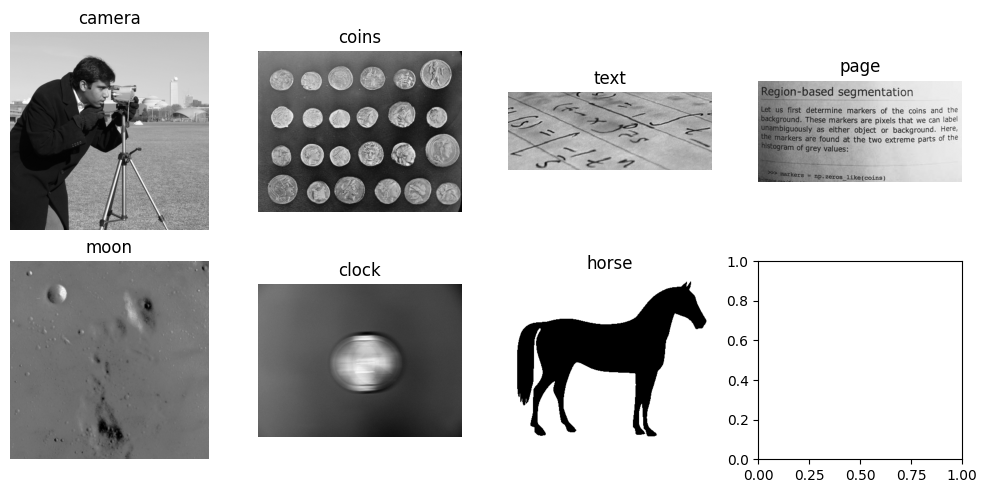

**Figura 6.1:** Algumas imagens públicas disponíveis em *skimage.data*.


In [37]:
import matplotlib.pyplot as plt
from skimage import data

imgs = {
    "camera": data.camera(),
    "coins": data.coins(),
    "text": data.text(),
    "page": data.page(),
    "moon": data.moon(),
    "clock": data.clock(),
    "horse": data.horse()
}

fig, ax = plt.subplots(2, 4, figsize=(10, 5))

for a, (nome, img) in zip(ax.ravel(), imgs.items()):
    a.imshow(img, cmap="gray")
    a.set_title(nome)
    a.axis("off")

plt.tight_layout()

## 6.2 Fundamentos de OMR e Inspeção Industrial

O **Reconhecimento Óptico de Marcas** (*Optical Mark Recognition* — OMR) é uma técnica de Visão Computacional destinada à identificação automática de marcações realizadas em posições previamente definidas de um formulário. Suas aplicações incluem folhas de respostas, questionários, formulários administrativos, pesquisas de opinião e diversos outros documentos estruturados.

Diferentemente do OCR (*Optical Character Recognition*), cujo objetivo é reconhecer caracteres e palavras, o OMR concentra-se na análise da presença, ausência ou intensidade de marcas em regiões específicas da imagem. Enquanto o OCR busca interpretar conteúdo textual, o OMR explora propriedades geométricas e estatísticas associadas ao preenchimento de áreas previamente conhecidas.

Os sistemas modernos de OMR operam sobre imagens obtidas por scanners, câmeras ou dispositivos móveis, utilizando técnicas de Processamento Digital de Imagens e Visão Computacional para automatizar tarefas que, tradicionalmente, dependiam de equipamentos especializados.

De forma geral, um pipeline de OMR é composto pelas seguintes etapas:

1. **Aquisição da imagem:** conversão do documento físico em uma representação digital.
2. **Pré-processamento:** correção geométrica, redução de ruídos e binarização.
3. **Localização das regiões de interesse:** identificação das áreas destinadas às marcações.
4. **Análise das marcações:** avaliação do preenchimento das regiões candidatas.
5. **Interpretação dos resultados:** conversão das marcações detectadas em respostas, dados ou indicadores quantitativos.

Os mesmos princípios são amplamente utilizados em sistemas de **Inspeção Industrial**, nos quais imagens são analisadas automaticamente para verificar a qualidade de produtos e processos. Entre as aplicações mais comuns estão a verificação da presença de componentes, a detecção de defeitos, a medição de dimensões e a validação de características geométricas.

Sob a perspectiva computacional, tanto o OMR quanto a inspeção industrial compartilham um mesmo fluxo de processamento: aquisição da imagem, segmentação de regiões relevantes, extração de características e tomada de decisão automatizada. Por esse motivo, as técnicas estudadas neste capítulo possuem aplicação direta em ambos os domínios.

## 6.3 Projetos Práticos: Construção de um Pipeline de Análise Documental

Os conceitos apresentados neste capítulo serão desenvolvidos por meio de projetos práticos que reproduzem etapas típicas de sistemas reais de análise documental. Cada projeto introduz técnicas fundamentais que serão reutilizadas em tarefas de OCR, OMR, inspeção visual e processamento de formulários.

### 6.3.1 Alinhamento Automático de Documentos (*OCR/OMR Pre-processing*)

A correção de inclinação (*deskew*) é uma das etapas mais importantes no processamento de documentos. Durante a digitalização ou captura por dispositivos móveis, pequenas rotações podem ser introduzidas na imagem, dificultando a localização de regiões de interesse e comprometendo a precisão dos algoritmos de segmentação e reconhecimento.

Neste projeto será desenvolvido um sistema capaz de estimar automaticamente a orientação predominante de um documento e corrigir sua inclinação. Para isso, serão utilizadas técnicas clássicas de detecção de bordas e de identificação de retas baseadas no operador de Canny e na Transformada de Hough.

A partir das linhas estruturais detectadas, será estimado o ângulo de rotação do documento. Em seguida, uma transformação afim será aplicada para produzir uma versão alinhada da imagem, preservando sua estrutura geométrica e facilitando as etapas posteriores de análise.

Antes da correção geométrica, o documento precisa ser convertido para um formato compatível com as bibliotecas de Visão Computacional. Como muitos formulários e folhas de resposta são distribuídos em formato PDF, a primeira etapa do pipeline consiste na rasterização de cada página, transformando-a em uma imagem digital composta por uma matriz de pixels.

Neste capítulo, essa conversão será realizada com a biblioteca `pdf2image`, gerando imagens PNG com resolução de 200 DPI (*dots per inch*). A partir dessas imagens, torna-se possível aplicar técnicas de detecção de bordas, Transformada de Hough, segmentação, extração de contornos e reconhecimento automático de padrões.

[INGESTÃO] Página PDF convertida com sucesso: test01.png
[INGESTÃO] Página PDF convertida com sucesso: test02.png
[INGESTÃO] Página PDF convertida com sucesso: test03.png


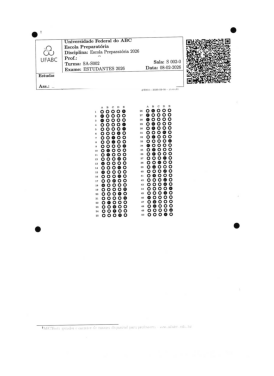

**Figura 6.2:** Pipeline de ingestão de documentos: rasterização adaptativa de páginas PDF para matrizes discretas em formato PNG.


In [61]:
import os
import cv2
from pdf2image import convert_from_path
from skimage import data
from morph import mm

# Diretório dos microdados e folhas de respostas do exame institucional
file_path = "dados/provas_qrcode_EP.pdf"

if os.path.exists(file_path):
    # Rasterização das páginas com resolução otimizada de 200 DPI
    pages = convert_from_path(file_path, dpi=200)
    for i, page in enumerate(pages):
        saida = f"test{i+1:02d}.png"
        page.save(saida)
        print(f"[INGESTÃO] Página PDF convertida com sucesso: {saida}")
else:
    print("[AVISO] Arquivo PDF não localizado no path. Ativando fallback via skimage.data.")
    # Injeta matriz de texto pública para garantir a execução contínua do pipeline
    img_fallback = data.text()
    cv2.imwrite("test02.png", img_fallback)
    print("[INGESTÃO] Imagem de fallback estruturada: test02.png")

# Carrega e exibe a imagem rasterizada inicial utilizando o ecossistema morph
img_original = mm.read('test02.png')
mm.show(img_original, figsize=(4, 3))

### 6.3.2 Algoritmo de Retificação de Inclinação (*Deskew*)

A etapa de *deskew* tem como objetivo estimar e corrigir a inclinação global de um documento digitalizado. A Figura [Figura 6.3](#fig-06-comparativo-pipeline) apresenta as principais etapas do processo: a imagem original, o mapa de bordas obtido pelo operador de Canny e o documento após a correção geométrica.

O algoritmo implementado neste capítulo é composto por três etapas principais:

1. detecção de bordas com o operador de Canny;
2. estimação da orientação predominante por meio da Transformada de Hough;
3. aplicação de uma transformação afim de rotação para corrigir a inclinação.

Após a correção, o documento passa a apresentar alinhamento mais consistente com os eixos da imagem, facilitando as etapas posteriores de segmentação, extração de componentes conexos e reconhecimento de marcas.

### 6.3.3 Modelagem Matemática

#### 6.3.3.1 Detecção de Bordas

Inicialmente, a imagem é suavizada por um filtro Gaussiano para reduzir ruídos e pequenas variações locais de intensidade. Os fundamentos da filtragem espacial e da convolução foram apresentados no Capítulo 3. Em seguida, o operador de Canny calcula a magnitude do gradiente da imagem:

$$
|\nabla f| =
\sqrt{
\left(\frac{\partial f}{\partial x}\right)^2 +
\left(\frac{\partial f}{\partial y}\right)^2
}.
$$

Após a supressão de não-máximos e a limiarização por histerese, obtém-se uma imagem binária contendo as principais bordas presentes no documento.

#### 6.3.3.2 Transformada de Hough

Os pixels de borda são então analisados pela Transformada de Hough Linear. Cada ponto $(x,y)$ contribui para o conjunto de retas descrito por

$$
\rho = x \cos\theta + y \sin\theta.
$$

Os máximos da matriz acumuladora correspondem às estruturas lineares predominantes da imagem. Em documentos, essas estruturas podem corresponder às bordas da página, linhas de tabelas, formulários ou ao próprio alinhamento das linhas de texto.

O código seleciona os ângulos pertencentes ao intervalo $[-45^\circ,45^\circ]$ e utiliza a mediana desses valores como estimativa da inclinação global do documento. Essa estratégia reduz a influência de detecções isoladas e produz uma estimativa mais estável da orientação predominante.

#### 6.3.3.3 Rotação Afim

Conhecido o ângulo estimado, aplica-se uma transformação afim de rotação em torno do centro da imagem. As transformações afins foram introduzidas no Capítulo 2, onde foram estudadas operações de translação, escala, cisalhamento e rotação em coordenadas homogêneas.

A função `mm.rotate` implementa essa transformação utilizando interpolação bicúbica, produzindo uma imagem alinhada e preservando a qualidade visual dos contornos e caracteres.

Como a rotação gera regiões sem informação nos limites da imagem, uma máscara adicional é utilizada para identificar esses pixels e substituí-los por branco, produzindo um resultado mais adequado para as etapas posteriores de análise documental.

### 6.3.4 Limitações Práticas

O desempenho do algoritmo depende da presença de estruturas lineares suficientemente visíveis para serem detectadas pela Transformada de Hough. Embora bordas do documento e linhas de formulários contribuam significativamente para a estimativa angular, o método também pode utilizar o alinhamento das próprias linhas de texto para inferir a orientação global da página.

Entretanto, imagens com baixa resolução, ruído excessivo, sombras intensas ou inclinações muito elevadas podem reduzir a precisão da estimativa. Na prática, documentos digitalizados com resolução próxima de 200 DPI e iluminação homogênea costumam fornecer resultados adequados para as etapas subsequentes de OCR e OMR.

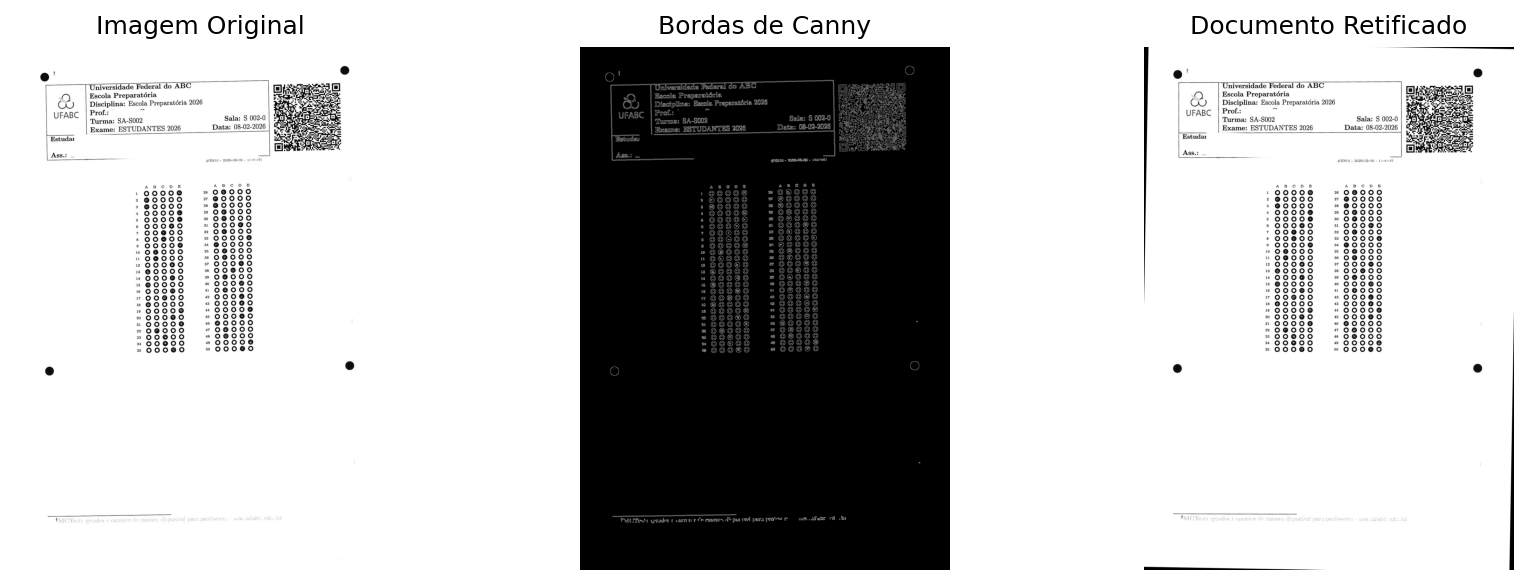

**Figura 6.3:** Pipeline de retificação axial: exibição comparativa entre a entrada rotacionada original, o mapa de gradientes estruturais de Canny e o resultado final alinhado com fundo normalizado em branco.


In [71]:
import cv2
import numpy as np
from morph import mm

def retificar_inclinacao_documento(img):

    gray = mm.gray(img) if img.ndim == 3 else img
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5,5), 0), 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

    if lines is None:
        return edges, img

    angulos = []
    for line in lines:
        angulo = np.rad2deg(line[0][1]) - 90
        if -45 < angulo < 45:
            angulos.append(angulo)

    if not angulos:
        return edges, img

    return edges, mm.rotate(img, np.median(angulos), interp="bicubic")

# Execução do pipeline de deskew
img_edges, img_final = retificar_inclinacao_documento(img_original)

# Exibição múltipla padronizada com o formato nativo do livro
mm.show(
    [img_original, img_edges, img_final],
    titles=["Imagem Original", "Bordas de Canny", "Documento Retificado"],
    cols=3,
    figsize=(12, 4)
)

O algoritmo apresentado nesta seção foi desenvolvido com o objetivo de ilustrar os princípios fundamentais da correção automática de inclinação utilizando detecção de bordas, Transformada de Hough e rotação afim. Por utilizar apenas as estruturas lineares predominantes da imagem, ele é suficientemente geral para funcionar em diversos tipos de documentos, formulários e páginas contendo texto.

Entretanto, sistemas reais de OMR costumam explorar informações geométricas adicionais para aumentar a robustez do alinhamento. No modelo de folha de respostas utilizado pelo ecossistema MCTest, por exemplo, existem quatro discos pretos de referência posicionados próximos às extremidades do documento, além das regiões correspondentes ao cabeçalho, ao QR Code de identificação e aos quadros de respostas.

Nessa situação, o alinhamento pode ser realizado a partir da localização explícita desses marcadores geométricos, permitindo estimar com maior precisão a rotação, a escala e eventuais deslocamentos da folha. Como os discos possuem posição conhecida no formulário, o processo torna-se menos sensível à quantidade de texto presente na página, à ausência de linhas estruturais e a pequenas variações de impressão ou digitalização.

Por esse motivo, embora a estratégia baseada na Transformada de Hough seja amplamente utilizada e adequada para fins didáticos, a utilização de marcadores conhecidos constitui uma solução mais robusta para sistemas de correção automatizada de provas e formulários estruturados, sendo a abordagem adotada nas etapas posteriores deste capítulo.

## 6.4 Equalização Local de Contraste com CLAHE

A qualidade da segmentação depende diretamente do contraste da imagem de entrada. Em documentos digitalizados é comum encontrar variações de iluminação, sombras, regiões superexpostas e diferenças de tonalidade do papel, fatores que dificultam a separação entre primeiro plano e fundo por meio de um limiar global.

Uma estratégia amplamente empregada consiste em melhorar inicialmente o contraste local utilizando a técnica **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*), apresentada no Capítulo 4. Diferentemente da equalização global de histograma, o CLAHE divide a imagem em pequenas regiões (*tiles*) e equaliza cada uma delas individualmente, limitando a amplificação do contraste para evitar o realce excessivo do ruído.

A Figura [Figura 6.4](#fig-06-clahe-page) ilustra esse procedimento utilizando a imagem `page()` da biblioteca `skimage.data`, amplamente empregada em experimentos de OCR e análise documental. Inicialmente, aplica-se a limiarização de Otsu diretamente sobre a imagem original. Em seguida, a mesma limiarização é realizada após a aplicação do CLAHE.

Observa-se que a equalização local aumenta o contraste entre o texto e o fundo do documento, permitindo que a limiarização de Otsu produza uma imagem binária mais homogênea. Embora o algoritmo permaneça o mesmo, a melhoria do contraste reduz a influência de pequenas variações de iluminação e facilita as etapas posteriores de extração de contornos, rotulação de componentes conexos, OCR e OMR.

No projeto desenvolvido na seção anterior, a folha de respostas utilizada como exemplo foi obtida por digitalização em condições controladas de iluminação. Por esse motivo, a limiarização direta foi suficiente para o processo de retificação geométrica. Em aplicações práticas, entretanto, documentos frequentemente são capturados por câmeras de dispositivos móveis ou em ambientes com iluminação não uniforme. Nesses casos, a aplicação do CLAHE antes da limiarização costuma aumentar a robustez da segmentação e melhorar a qualidade das etapas subsequentes do pipeline de Visão Computacional.

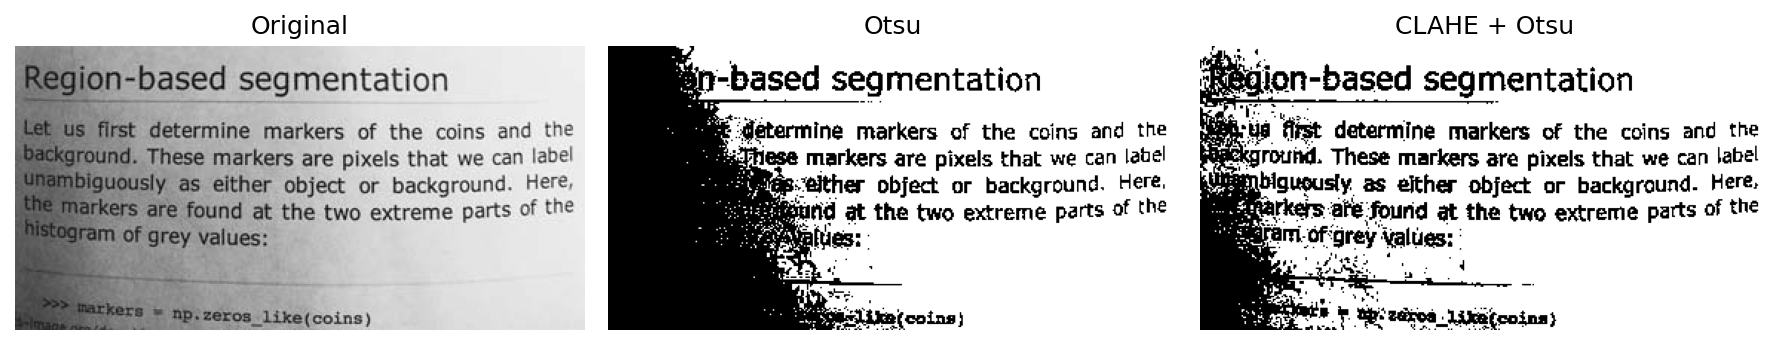

**Figura 6.4:** Influência da equalização local de contraste (CLAHE) na limiarização por Otsu.


In [84]:
import cv2
from skimage import data
from morph import mm

img = data.page() # ou
# img = mm.gray(img_final) # com image da folha de prova
img_otsu = mm.threshold(img)

img_clahe = cv2.createCLAHE(2.0, (8,8)).apply(img)
img_clahe_otsu = mm.threshold(img_clahe)

mm.show(
    [img, img_otsu, img_clahe_otsu],
    titles=["Original", "Otsu", "CLAHE + Otsu"],
    cols=3,
    figsize=(12,4)
)

---

## 6.5 Mão na Massa: Exercícios Práticos

O aprendizado em Visão Computacional acontece **praticando em casos reais**. Os exercícios abaixo progressivamente aumentam em complexidade e aproximam você do desafio de implementar sistemas de VC profissionais.

### 6.5.1 Exercício 1: Validação Robusta contra Ruídos (Valor: 4,0 pontos)

**Contexto:** No Projeto 2, detectamos bolhas apenas pela **circularidade** e **área**. Porém, em documentos com baixa qualidade de scanner, manchas, rasgos ou sujeira podem ter área e circularidade similares às bolhas reais, causando falsos positivos.

**Desafio:** Implemente uma validação adicional baseada nos **Momentos Invariantes de Hu** ($h_1, h_2, \ldots, h_7$). Especificamente:
1. Calcule $h_1$ (primeiro momento invariante) para **uma elipse perfeita** e **um retângulo** de mesma área
2. Compare os valores—eles devem ser significativamente diferentes
3. Use $h_1$ como critério adicional de filtro no Projeto 2: aceitar apenas bolhas cujo $h_1$ se aproxime do valor de uma elipse
4. Teste o novo pipeline em imagens com diferentes níveis de ruído e compare a taxa de falsos positivos

**Saída esperada:** Um gráfico mostrando como a métrica $h_1$ reduz falsos positivos mantendo a detecção de bolhas reais.

---

### 6.5.2 Exercício 2: Detecção de Fraudes e Dupla Marcação (Valor: 6,0 pontos)

**Contexto:** Em avaliações reais, estudiantes frequentemente tentam fazer fraude:
- Marcar **duas alternativas na mesma questão** (indecisão ou tentativa de fraude)
- **Raspar ou apagar** uma marcação (deixando mancha cinza)
- **Marcar fora da bolha** (invalidando a resposta)

**Desafio:** Modifique o Projeto 2 para adicionar **validação de integridade**:
1. Para cada questão, se **duas ou mais alternativas** apresentarem preenchimento acima de $50\%$, marque como **"ANULADA — Dupla Marcação"**
2. Se o preenchimento ficar entre $30\%-50\%$ em qualquer alternativa, marque como **"SUSPEITA — Preenchimento Parcial"** (possível rasura)
3. Se nenhuma alternativa ultrapassar $45\%$, marque como **"BRANCO"**
4. Gere um **relatório detalhado** indicando quais questões têm problemas e o percentual de integridade do formulário

**Saída esperada:** Um relatório estruturado em JSON ou pandas DataFrame mostrando para cada questão: [resposta_lida, confiança, status_integridade].

---

### 6.5.3 Exercício 3: Pipeline Completo de End-to-End (Valor: 10,0 pontos — Desafio)

**Contexto:** Você agora tem os dois projetos funcionando separadamente. O desafio final é **integrá-los em um sistema único e robusto**.

**Desafio:**
1. Crie uma função `processar_prova_completa(caminho_pdf)` que:
   - Converta PDF para imagem (Projeto 1 — setup)
   - Alinhe a página automaticamente (Projeto 1)
   - Detecte e decodifique o QR Code (Projeto 2 — extração de ID)
   - Processe todas as bolhas com validação robusta (Proj 2 + Ex 1)
   - Detecte fraudes e anomalias (Projeto 2 + Ex 2)
   - Retorne um dicionário com: `{id_aluno, id_prova, gabarito_lido, confianca_media, questoes_problema, score_estimado}`

2. Teste em **múltiplas imagens** com variações:
   - Alinhamento perfeito vs. rotacionado ±10°
   - Qualidade de scanner alta vs. baixa
   - Documentos com fraudes vs. legítimos
   - Diferentes formatos de folha de resposta

3. Documente os **casos limites** onde o algoritmo falha e sugira melhorias

**Saída esperada:** Uma classe `ProcessadorProvas` reutilizável, com testes unitários e um notebook mostrando resultados em 5+ casos reais.

---

## 6.6 Próximos Passos

Após completar este capítulo, você estará pronto para:
- **Capítulo 7:** Detecção de objetos em cenas complexas (faces, pessoas, placas de carro)
- **Capítulo 8:** Reconhecimento de padrões e matching (buscar imagens similares)
- **Capítulo 9:** Rastreamento em vídeo (tracking de movimentos)
- **Capítulo 10:** Deep Learning para visão (CNN, Detecção em Tempo Real)